# Idea 2 - Evidence selection → extraction → constrained answering
1. Prompt VLM to list specific flowchart elements (conditions / decisions / outcomes) that are required to answer the question.
1. Prompt VLM to detect whether each listed element is present in the flowchart and extracts its values.
1. Prompt VLM to answer the question using only verified elements.

# Experiment
1. Try with a few samples
2. Evaluate dev score

In [1]:
# Helper functions
import base64
import os
import random
from typing import List
from PIL import Image
from openai import OpenAI
import pandas as pd
import json
from IPython.display import display, HTML


VLM_MODEL_ID = "openai/gpt-5.1-chat"
LLM_MODEL_ID = "openai/gpt-5.1-chat"
openai_client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=os.environ["OPENROUTER_API_KEY"])

# Load FlowVQA dev set JSON
with open("../data/flowvqa/dev.json", "r") as f:
    flowvqa_dev_set = json.load(f)

# Form a Pandas DataFrame
records = []
index = []
for k, v in flowvqa_dev_set.items():                
    for question_id, qa in v["qa"].items():
        answers = [qa["A1"], qa["A2"], qa["A3"]]
        records.append({
            "question_id": question_id,
            "question": qa["Q"],
            "answers": answers,
            "type": qa["type"]
        })
        index.append(k)
flowvqa_dev_df = pd.DataFrame(records, index=index)


'''
Sample 5 flowcharts from FlowVQA dev set for smoke test, with the constraint that:
    - 1 code flowchart
    - 1 wiki flowchart
    - 1 instruct flowchart
    - 2 randomly sampled flowcharts
Inputs:
    - boolean indicating whether to display the sampled flowcharts
    - random seed
    - maximum width or height for display (pixels)
Outputs:
    - list of sampled flowchart names
'''
def sample_5_flowcharts(
    display_flowchart: bool = False,
    seed: int | None = None
) -> List[str]:
    if seed is not None:
        random.seed(seed)  

    flowchart_names = list(flowvqa_dev_set.keys())

    code_flowchart = None
    instruct_flowchart = None
    wiki_flowchart = None
    for x in flowchart_names:
        if (not code_flowchart) and x.startswith("code"):
            code_flowchart = x
        elif (not instruct_flowchart) and x.startswith("instruct"):
            instruct_flowchart = x
        elif (not wiki_flowchart) and x.startswith("wiki"):
            wiki_flowchart = x
        if code_flowchart and instruct_flowchart and wiki_flowchart:
            break

    flowchart_names.remove(code_flowchart)
    flowchart_names.remove(instruct_flowchart)
    flowchart_names.remove(wiki_flowchart)
    random_samples = random.sample(flowchart_names, 2)
    sampled_flowcharts = [code_flowchart, instruct_flowchart, wiki_flowchart] + random_samples

    if display_flowchart:
        for p in sampled_flowcharts:
            # clear visual separation
            display(HTML("<hr style='margin:16px 0'>"))
            
            # show filename / context
            display(HTML(f"<div style='font-family:monospace;opacity:0.7'>{p}</div>"))
            
            # load and shrink image to avoid huge output
            img = Image.open(os.path.join("/app/data/flowvqa/images/", p + ".png"))
            img.thumbnail((400, 400))
            display(img)
            with pd.option_context('display.max_colwidth', None):
                display(flowvqa_dev_df.loc[p])
            
    return sampled_flowcharts


'''
Query the VLM with image and a text prompt.
Inputs:
    - image file path
    - text prompt
Outputs:
    - response by the VLM
'''
def query_VLM(image_path, prompt, max_new_tokens=4096, temperature=0.0):
    # encode as base64 binary
    with open(image_path, "rb") as image_file:
        image =  base64.b64encode(image_file.read()).decode("utf-8")

    messages = [
                {"role": "system", "content": "You are a helpful assistant."},
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{image}",
                                "detail": "high",
                            },
                        },
                    ],
                },
            ]

    completion = openai_client.chat.completions.create(
        model=VLM_MODEL_ID,
        max_tokens=max_new_tokens,
        temperature=temperature,
        messages=messages,
        extra_body={"provider": {"only": ["openai"]}},
    )
    
    response = completion.choices[0].message.content
    return response


'''
Query the LLM with a text prompt.
Inputs:
    - text prompt
Outputs:
    - response by the LLM
'''
def query_LLM(prompt, max_new_tokens=4096, temperature=0.0):
    messages = [
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt},
            ]

    completion = openai_client.chat.completions.create(
        model=LLM_MODEL_ID,
        max_tokens=max_new_tokens,
        temperature=temperature,
        messages=messages,
        extra_body={"provider": {"only": ["openai"]}},
    )
    
    response = completion.choices[0].message.content
    return response

# Sample 5 flowcharts for smoke test

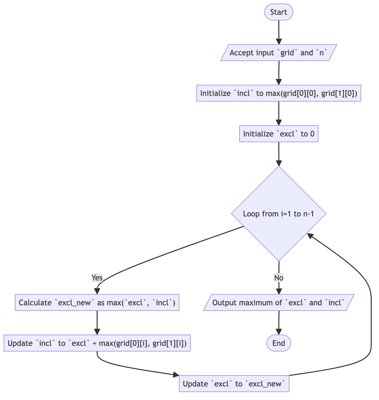

,question_id,question,answers,type
code00268,1,How is the initial value of 'incl' determined?,"[It is the maximum value of the first column of the grid., 'incl' is initialized to the greater of grid[0][0] or grid[1][0]., The starting value for 'incl' comes from the highest value in the grid's first column.]",fact_retrieval
code00268,2,"Imagine you are writing a program to process a grid of numbers for a game. You've just initialized two variables, `incl` and `excl`, and you're about to enter a loop that starts with `i=1`. In this loop, you need to update a variable `excl_new`. Based on the algorithm you're following, what value should `excl_new` be assigned?","[The maximum of `excl` and `incl`., The greater value between `excl` and `incl`., Choose the larger number from `excl` and `incl`.]",applied_scenario
code00268,3,"As you continue to iterate through the grid in your number-crunching application, you find yourself updating two variables, `incl` and `excl`, at each step. Once you have calculated the new value for `incl`, which involves adding the maximum of grid[0][i] or grid[1][i] to `excl`, what's the next immediate action you must take before the next iteration?","[Set the value of `excl` to `excl_new`., Update `excl` with the value of `excl_new`., Assign `excl_new` to `excl`.]",applied_scenario
code00268,4,"What will be the value of `incl` after the first iteration of the loop starting at node E, given that `grid` is a 2x2 matrix with values [[1,2],[3,4]]?","[The value of `incl` after the first iteration will be 5., After the first loop iteration, `incl` is updated to 5., 5 is the updated value of `incl` post the initial loop iteration.]",flow_referential
code00268,5,"If the loop at node E has completed two iterations for an input `n` of 3, what will be the sequence of steps executed up to the point of outputting the result?","[The sequence is initializing `incl` and `excl`, two iterations of calculating `excl_new`, updating `incl`, updating `excl`, and then outputting the maximum of `excl` and `incl`., First, initialize `incl` and `excl`, then perform two loop iterations involving the calculation of `excl_new`, the update of `incl`, and `excl`, and finally output the max of `excl` and `incl`., The steps are to initialize `incl` and `excl`, run two iterations for `excl_new` calculation, `incl` and `excl` updates, and conclude by outputting the larger of `excl` or `incl`.]",flow_referential
code00268,6,How many nodes exist in the given flowchart?,"[10, There are a total of ten nodes in the flowchart., Ten nodes in total]",topological
code00268,7,How many edges exist in the given flowchart?,"[10, There are ten edges in the flowchart., Ten Edges]",topological


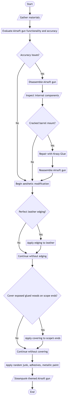

,question_id,question,answers,type
instruct00856,1,What should be done if there are accuracy issues with the Airsoft gun?,"[Disassemble the Airsoft gun, Take apart the gun for inspection, Begin disassembly for further inspection]",fact_retrieval
instruct00856,2,How should a cracked barrel mount on the Airsoft gun be repaired?,"[Repair it with Krazy Glue, Use Krazy Glue for the repair, Fix the cracked barrel mount with Krazy Glue]",fact_retrieval
instruct00856,3,"Liam is customizing an Airsoft gun to fit a Steampunk theme for his short film, but he's having trouble giving the leather pieces a finished look with perfect edging. If he can't figure out how to edge the leather properly, what should he do to keep the project moving forward?","[Continue the modification process without edging the leather., Proceed with the aesthetic changes without applying the leather edging., Carry on with the Steampunk modifications, leaving the leather unedged.]",applied_scenario
instruct00856,4,"Assuming the Airsoft gun has been disassembled due to accuracy issues, what would be the next step if the internal components inspection reveals no cracked barrel mount?","[If no cracked barrel mount is found, the next step would be 'Begin aesthetic modification'., Upon finding the barrel mount intact, the subsequent action is to start the 'Begin aesthetic modification' process., The following step after an intact barrel mount inspection would be to proceed with 'Begin aesthetic modification'.]",flow_referential
instruct00856,5,How many nodes exist in the given flowchart?,"[19, There are nineteen nodes in the flowchart., Nineteen Nodes]",topological
instruct00856,6,How many edges exist in the given flowchart?,"[22, There are twenty-two edges in the flowchart., Twenty-two Edges]",topological
instruct00856,7,"Is the node """"Steampunk-themed Airsoft gun"""" direct predecessor of the node """"Apply edging to leather""""?","[No, No, the node 'Steampunk-themed Airsoft gun' is not a direct predecessor of 'Apply edging to leather'., No direct predecessor relationship exists]",topological
instruct00856,8,"How many edges exist in the shortest path between """"Cracked barrel mount?"""" and """"Steampunk-themed Airsoft gun""""?","[7, There are seven edges in the shortest path between 'Cracked barrel mount' and 'Steampunk-themed Airsoft gun'., Seven edges in the shortest path between 'Cracked barrel mount' and 'Steampunk-themed Airsoft gun'.]",topological
instruct00856,9,An indegree of is the number of incoming edges for a node in a flowchart. What is the maximum indegree for the flowchart?,"[3, The maximum indegree for the flowchart is 3., Three is the maximum indegree for the flowchart.]",topological


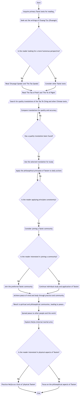

,question_id,question,answers,type
wiki00071,1,What book should be read for a humorous take on Taoist philosophy?,"['Zhuangzi Speaks' and 'The Tao Speaks', Read 'Zhuangzi Speaks' and 'The Tao Speaks', 'Zhuangzi Speaks' and 'The Tao Speaks' books]",fact_retrieval
wiki00071,2,What should one seek when searching for translations of the Tao Te Ching?,"[Quality and accuracy, Translations with high quality and accuracy, Accurate and high-quality translations]",fact_retrieval
wiki00071,3,"Assuming I'm at the step where I'm comparing translations for quality and accuracy, and I eventually find a quality translation, what are the immediate next two steps in the process?","[The immediate next steps would be 'Use the selected translation for study' followed by 'Apply the philosophical principles of Taoism to daily actions'., Upon finding a quality translation, the subsequent steps are to use that translation for study and then to apply Taoism's philosophical principles consistently in daily life., After confirming a quality translation, the next steps involve studying the translation and integrating Taoist philosophy into everyday actions.]",flow_referential
wiki00071,4,How many nodes exist in the given flowchart?,"[25, There are twenty-five nodes in the flowchart., Twenty-five Nodes]",topological
wiki00071,5,How many edges exist in the given flowchart?,"[29, There are twenty-nine edges in the flowchart., Twenty-nine Edges]",topological
wiki00071,6,"Is the node """"Read 'The Tao of Pooh' and 'The Te of Piglet'"""" direct predecessor of the node """"Focus on the philosophical aspects of Taoism""""?","[No, No, the node 'Read 'The Tao of Pooh' and 'The Te of Piglet' is not a direct predecessor of 'Focus on the philosophical aspects of Taoism.', No direct predecessor relationship exists]",topological


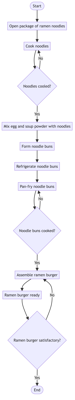

,question_id,question,answers,type
instruct00665,1,"After mixing the egg and soup powder with noodles, what is the next step?","[Form noodle buns, Next, form the noodles into buns, The following step is to shape the noodle mixture into buns]",fact_retrieval
instruct00665,2,"Leo is preparing to make ramen burgers for his food blog and wants to capture every detail of the process. After boiling the noodles, what critical step should he document next to ensure the noodles are ready for the subsequent stages?","[Leo should document the cooling of the noodles, which is critical before mixing them with egg and soup powder., He needs to capture the straining and cooling process of the noodles before proceeding to mix them with other ingredients., The next step Leo should show is the cooling of the noodles post-boiling to prepare them for mixing with the egg and soup powder.]",applied_scenario
instruct00665,3,"If I'm currently at the step where I need to refrigerate noodle buns, what was the immediate previous step and what is the next step?","[The immediate previous step was forming noodle buns, and the next step is to pan-fry the noodle buns., Before refrigerating the noodle buns, you would have formed the noodle buns, and afterwards, you will need to pan-fry them., You would have just formed the noodle buns, and after refrigeration, the noodle buns are to be pan-fried.]",flow_referential
instruct00665,4,How many nodes exist in the given flowchart?,"[13, There are thirteen nodes in the flowchart provided., Thirteen Nodes]",topological
instruct00665,5,How many edges exist in the given flowchart?,"[15, There are fifteen edges in the flowchart., Fifteen Edges]",topological
instruct00665,6,"Is the node """"Ramen burger satisfactory?"""" direct successor of the node """"Refrigerate noodle buns""""?","[No, No, the node 'Ramen burger satisfactory?' is not a direct successor of 'Refrigerate noodle buns'., No direct successor relationship exists]",topological
instruct00665,7,"How many edges exist in the shortest path between """"Assemble ramen burger"""" and """"End""""?","[3, There are three edges in the shortest path between 'Assemble ramen burger' and 'End'., Three edges exist in the shortest path from 'Assemble ramen burger' to 'End'.]",topological
instruct00665,8,"Is the node """"Ramen burger satisfactory?"""" direct successor of the node """"Ramen burger ready""""?","[Yes, Yes, the node 'Ramen burger satisfactory?' is a direct successor of the node 'Ramen burger ready'., The node 'Ramen burger satisfactory?' is indeed a direct successor of 'Ramen burger ready'.]",topological


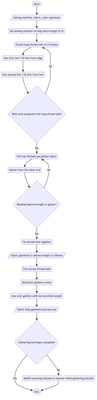

,question_id,question,answers,type
instruct00286,1,What stitch length should be set on the sewing machine for gathering fabric?,"[A long stitch length of 3-4, Set the machine to a stitch length between 3 and 4, Adjust the stitch length to between 3 and 4 for gathering]",fact_retrieval
instruct00286,2,How far from the edge should the first line of stitching be when gathering fabric?,"[1/8 inch from the edge, Sew the first line of stitching 1/8 inch away from the fabric edge, The initial stitching line should be 1/8 inch from the edge of the fabric]",fact_retrieval
instruct00286,3,What is the final step to secure the gathers in the fabric?,"[Sew over the gathers with a normal stitch length, Secure the gathers by sewing over them using a standard stitch length, Finish by sewing across the gathers with the sewing machine set to a normal stitch length]",fact_retrieval
instruct00286,4,"Liam has gathered his fabric to the correct fullness and has secured the gathers by tying the thread tails. However, he's unsure if he should cut off the excess thread right away. What is the next step he should take according to the instructions?","[Liam should trim the excess thread tails after securing the gathers., He should proceed to cut off the excess thread tails now that the gathers are secured., The next step for Liam is to remove the excess thread tails following the securing of the gathers.]",applied_scenario
instruct00286,5,"If I am currently at the step where I am pulling the top threads to gather the fabric, but find that the gathers are not to the desired length, what will my next two steps be?","[You would gather from the other end, then check if you've reached the desired length or gather., Next, you would proceed to gather from the opposite end and subsequently evaluate if the desired length or fullness has been achieved., The subsequent steps involve gathering from the opposite side and then assessing if the desired gather length has been met.]",flow_referential
instruct00286,6,"Assuming I have just finished sewing over the gathers with a normal stitch length, but the gathering technique is not yet complete, what is my immediate next action?","[You would modify securing stitches or remove initial gathering stitches., The immediate action is to adjust the securing stitches or undo the initial gathering stitches., Next, you would either revise the stitches that secure the gathers or take out the stitches from the initial gathering.]",flow_referential
instruct00286,7,How many nodes exist in the given flowchart?,"[19, There are nineteen nodes in the flowchart., Nineteen Nodes]",topological
instruct00286,8,How many edges exist in the given flowchart?,"[21, There are twenty-one edges in the flowchart., Twenty-one Edges]",topological
instruct00286,9,"How many edges exist in the shortest path between """"Tie thread tails together"""" and """"Fabric gathered to desired length or fullness""""?","[1, There is only one edge in the shortest path between 'Tie thread tails together' and 'Fabric gathered to desired length or fullness'., One edge in the shortest path between 'Tie thread tails together' and 'Fabric gathered to desired length or fullness'.]",topological
instruct00286,10,"Is the node """"End"""" direct successor of the node """"Modify securing stitches or remove initial gathering stitches""""?","[Yes, Yes, the node 'End' is a direct successor of the node 'Modify securing stitches or remove initial gathering stitches.', The node 'End' directly follows the node 'Modify securing stitches or remove initial gathering stitches.']",topological


['code00268', 'instruct00856', 'wiki00071', 'instruct00665', 'instruct00286']

In [2]:
sample_5_flowcharts(True, 888)

# Implement idea

In [3]:
import json, re


def list_relevant_flowchart_elements(question):
    prompt_template = """# Task
Given a question whose answer must be derived from a flowchart image, identify the specific flowchart elements or structural properties that are strictly necessary to determine the answer.

Do NOT answer the question.
Do NOT infer whether the elements actually exist in the flowchart.
Only list what must be checked in the flowchart to answer the question.

Question: {question}

# Valid element types
You may output up to 10 items. Each item must be one of the following:

- a flowchart node corresponding to a specific concept mentioned or implied in the question
- upstream nodes (ancestors) of a specified node
- downstream nodes (descendants) of a specified node
- the total number of nodes
- the total number of edges
- a structural relationship between nodes (e.g., which node precedes another, whether two nodes are connected)
- path between two specified nodes (e.g., shortest path, direct path)
- non-flowchart givens explicitly stated in the question that must be used to determine the answer

Each element must refer to specific concepts or entities appearing in the question. Avoid vague descriptions such as "relevant nodes" or "important steps".

Prefer the smallest set of elements sufficient to determine the answer.

# Output format
- Output only a bullet list.
- Do not include explanations or reasoning.

# Few-shot examples

## Example 1
Question: How many nodes are there?

Output:
- the total number of nodes

## Example 2
Question: How many edges exist in the flowchart?

Output:
- the total number of edges

## Example 3
Question: What should be done before writing code?

Output:
- the node corresponding to the action of writing code
- upstream nodes of the node corresponding to the action of writing code

# Output
"""
    return query_LLM(
        prompt_template.format(question=question)
    )


_JSON_FENCE = re.compile(r"```(?:json)?\s*([\s\S]*?)\s*```", re.IGNORECASE)
_FIRST_OBJECT = re.compile(r"\{[\s\S]*\}")
_FIRST_ARRAY = re.compile(r"\[[\s\S]*\]")

def parse_llm_json(text):
    candidates: list[str] = []

    candidates.append(text)

    m = _JSON_FENCE.search(text)
    if m:
        candidates.append(m.group(1))

    m = _FIRST_OBJECT.search(text)
    if m:
        candidates.append(m.group(0))

    m = _FIRST_ARRAY.search(text)
    if m:
        candidates.append(m.group(0))

    for s in candidates:
        s = s.strip()
        if not s:
            continue
        try:
            return json.loads(s)
        except json.JSONDecodeError:
            pass

    return None

    
def extract_flowchart_elements(flowchart_image, flowchart_elements, verbose=False):
    prompt_template = """# Task
Given:
(1) a list of flowchart elements or properties, and
(2) an image containing a flowchart,

for each listed item, determine whether it can be verified from the image
(explicitly visible or unambiguously derivable by counting nodes or tracing arrows),
and extract its value.

Do NOT assume an element exists.
Only mark an element as found if it is explicitly visible or unambiguously derivable.

If uncertain whether an element exists, return found=false and value=null.
Do not guess or infer missing nodes.

List of flowchart elements or properties:
{flowchart_elements}

# Extraction rules

- For **"total number of nodes"** or **"total number of edges"**:
  - If derivable from the flowchart, return an integer.
  - Otherwise return null and found=false.

- For **"the node corresponding to <concept>"**:
  - Identify nodes whose meaning corresponds to the concept, even if the wording differs.
  - If found, return the exact node text (verbatim) as it appears in the flowchart.
  - If not found, return null and found=false.

- For **"upstream nodes of <node>"** or **"downstream nodes of <node>"**:
  - Identify nodes connected through directed edges.
  - If found, return a list of node texts (verbatim) as they appear in the flowchart.
  - Return all relevant nodes without summarizing or omitting nodes unless the structure is ambiguous.
  - If none found, return null and found=false.

- For **path/relationship items** such as "<A> progressing to <B>" or "path between two nodes":
  - If both nodes exist and a path exists, return the node texts along the path.
  - The returned value must be a list ordered according to traversal of the path.
  - If both nodes exist but no path exists, return false.
  - If either node cannot be found, return null and found=false.

# Output format

Output ONLY a valid JSON array.
Do NOT include markdown, code blocks, explanations, or additional text.

The output must follow this structure:

[
  {{
    "element": "<exact input string>",
    "found": true | false,
    "value": <integer | string | boolean | list | null>
  }}
]

Requirements:
- The "element" field must exactly match the input string.
- The number of objects must equal the number of input items.
- If an element is not found, set "found": false and "value": null.
"""
    
    max_tries = 10
    parsed_response = None

    for attempt in range(1, max_tries + 1):
        response = query_VLM(
            flowchart_image,
            prompt_template.format(flowchart_elements=flowchart_elements)
        )

        parsed_response = parse_llm_json(response)
        if parsed_response is not None:
            break

        if verbose:
            print(f"\n[Attempt {attempt}/{max_tries} of detect_flowchart_elements] JSON parse failed.")
            print("Raw LLM response:")
            print("-" * 80)
            print(response)
            print("-" * 80)

    if parsed_response is None:
        raise ValueError(
            f"Failed to parse valid JSON from step 2 LLM output after {max_tries} attempts."
        )
    
    if verbose:
        print("detect_flowchart_elements parsed JSON:")
        print("-" * 80)
        print(json.dumps(parsed_response, indent=4))
        print("-" * 80)

    return parsed_response


def answer_question(flowchart_image, extracted_flowchart_elements, question):
    prompt_template = """# Task
You are given an image of a flowchart, a question and a JSON object containing elements or properties extracted from the flowchart.
Your task is to answer the question based on the flowchart. 
You are highly ENCOURAGED to use extracted flowchart elements or properties to assist you in answering the question but it is NOT A MUST.

You MUST always look at the flowchart image when deriving the answer because the extracted flowchart elements or properties might not be sufficient to answer the question.  
Do NOT guess the answer.
You MUST only give an answer that is derivable from the flowchart or the extracted flowchart elements or properties.

# Relevant flowchart elements or properties
```json
{extracted_flowchart_elements_in_json}
```

Question: {question}

# Output
"""
    return query_VLM(
        flowchart_image,
        prompt_template.format(
            extracted_flowchart_elements_in_json=json.dumps(extracted_flowchart_elements, indent=4),
            question=question)
    )

def pipeline(flowchart_image, question, verbose=False):
    listed_flowchart_elements = list_relevant_flowchart_elements(question)
    if verbose:
        print("Step 1 - List relevant flowchart elements")
        print("-" * 80)
        print(listed_flowchart_elements)
        print("-" * 80)

    if verbose:
          print("Step 2 - Extract flowchart elements' values")
    extracted_flowchart_elements = extract_flowchart_elements(flowchart_image, listed_flowchart_elements, verbose)

    final_answer = answer_question(flowchart_image, extracted_flowchart_elements, question)
    if verbose:
        print("Step 3 - Answer question")
        print("-" * 80)
        print(final_answer)
        print("-" * 80)

    return final_answer, {
        "step 1": listed_flowchart_elements,
        "step 2": extracted_flowchart_elements,
        "step 3": final_answer
    }

In [26]:
print(list_relevant_flowchart_elements("Is the node ""Steampunk-themed Airsoft gun"" direct predecessor of the node ""Apply edging to leather""?"))

- the node Steampunk-themed Airsoft gun  
- the node Apply edging to leather  
- structural relationship between Steampunk-themed Airsoft gun and Apply edging to leather (whether one directly precedes the other)


In [27]:
print(list_relevant_flowchart_elements("How many nodes exist in the given flowchart?"))

- the total number of nodes


In [28]:
print(list_relevant_flowchart_elements("How many edges exist in the given flowchart?"))

- the total number of edges


In [29]:
print(list_relevant_flowchart_elements("How is the initial value of 'incl' determined?"))

- the node corresponding to the initial assignment of 'incl'


In [30]:
print(list_relevant_flowchart_elements('How many edges exist in the shortest path between ""Cracked barrel mount?"" and ""Steampunk-themed Airsoft gun""?'))

- the node corresponding to "Cracked barrel mount?"
- the node corresponding to "Steampunk-themed Airsoft gun"
- path between "Cracked barrel mount?" and "Steampunk-themed Airsoft gun"


In [31]:
print(list_relevant_flowchart_elements("Imagine you are writing a program to process a grid of numbers for a game. You've just initialized two variables, `incl` and `excl`, and you're about to enter a loop that starts with `i=1`. In this loop, you need to update a variable `excl_new`. Based on the algorithm you're following, what value should `excl_new` be assigned?"))

- the node where `excl_new` is assigned
- upstream nodes of the node where `excl_new` is assigned
- non-flowchart givens: initialization of `incl` and `excl`
- non-flowchart givens: loop starting with `i=1`


In [34]:
extract_flowchart_elements("/app/data/flowvqa/images/code00268.png", """- the node where `excl_new` is assigned
- upstream nodes of the node where `excl_new` is assigned
- non-flowchart givens: initialization of `incl` and `excl`
- non-flowchart givens: loop starting with `i=1`""")

[{'element': 'the node where `excl_new` is assigned',
  'found': True,
  'value': 'Calculate `excl_new` as max(`excl`, `incl`)'},
 {'element': 'upstream nodes of the node where `excl_new` is assigned',
  'found': True,
  'value': ['Loop from i=1 to n-1']},
 {'element': 'non-flowchart givens: initialization of `incl` and `excl`',
  'found': True,
  'value': ['Initialize `incl` to max(grid[0][0], grid[1][0])',
   'Initialize `excl` to 0']},
 {'element': 'non-flowchart givens: loop starting with `i=1`',
  'found': True,
  'value': 'Loop from i=1 to n-1'}]

In [37]:
extract_flowchart_elements("/app/data/flowvqa/images/instruct00856.png", """- the node corresponding to "Cracked barrel mount?"
- the node corresponding to "Steampunk-themed Airsoft gun"
- path between "Cracked barrel mount?" and "Steampunk-themed Airsoft gun""")

[{'element': 'the node corresponding to "Cracked barrel mount?"',
  'found': True,
  'value': 'Cracked barrel mount?'},
 {'element': 'the node corresponding to "Steampunk-themed Airsoft gun"',
  'found': True,
  'value': 'Steampunk-themed Airsoft gun'},
 {'element': 'path between "Cracked barrel mount?" and "Steampunk-themed Airsoft gun',
  'found': True,
  'value': ['Cracked barrel mount?',
   'Repair with Krazy Glue',
   'Reassemble Airsoft gun',
   'Begin aesthetic modification',
   'Perfect leather edging?',
   'Continue without edging',
   'Cover exposed glued woods on scope ends?',
   'Continue without covering',
   'Apply random junk, adhesives, metallic paint',
   'Steampunk-themed Airsoft gun']}]

In [44]:
extract_flowchart_elements("/app/data/flowvqa/images/instruct00856.png", "- the total number of edges")

[{'element': 'the total number of edges', 'found': True, 'value': 22}]

In [45]:
extract_flowchart_elements("/app/data/flowvqa/images/instruct00856.png", '''- the node Steampunk-themed Airsoft gun  
- the node Apply edging to leather  
- the structural relationship of whether Steampunk-themed Airsoft gun directly precedes Apply edging to leather''')

[{'element': 'the node Steampunk-themed Airsoft gun',
  'found': True,
  'value': 'Steampunk-themed Airsoft gun'},
 {'element': 'the node Apply edging to leather',
  'found': True,
  'value': 'Apply edging to leather'},
 {'element': 'the structural relationship of whether Steampunk-themed Airsoft gun directly precedes Apply edging to leather',
  'found': True,
  'value': False}]

# Smoke test on pipeline

In [38]:
samples = [
    ("code00268", "Imagine you are writing a program to process a grid of numbers for a game. You've just initialized two variables, `incl` and `excl`, and you're about to enter a loop that starts with `i=1`. In this loop, you need to update a variable `excl_new`. Based on the algorithm you're following, what value should `excl_new` be assigned?","The maximum of `excl` and `incl`."),
    ("code00268", "How many nodes exist in the given flowchart?", "10"),
    ("code00268", "How many edges exist in the given flowchart?", "10"),
    ("instruct00856", 'Is the node ""Steampunk-themed Airsoft gun"" direct predecessor of the node ""Apply edging to leather""?', "No"),
    ("instruct00856", 'How many edges exist in the shortest path between ""Cracked barrel mount?"" and ""Steampunk-themed Airsoft gun""?', "7")
]

In [39]:
for flowchart_name, qn, gt in samples:
    print("Question:", qn)
    print()
    pipeline(f"/app/data/flowvqa/images/{flowchart_name}.png", qn, verbose=True)
    print()
    print("GT:", gt)
    print("=" * 100)

Question: Imagine you are writing a program to process a grid of numbers for a game. You've just initialized two variables, `incl` and `excl`, and you're about to enter a loop that starts with `i=1`. In this loop, you need to update a variable `excl_new`. Based on the algorithm you're following, what value should `excl_new` be assigned?

Step 1 - List relevant flowchart elements
--------------------------------------------------------------------------------
- the node corresponding to initializing variables incl and excl  
- the node where the loop begins with i = 1  
- the node where excl_new is assigned  
- upstream nodes of the node where excl_new is assigned  
- non-flowchart givens explicitly stated in the question (initial values of incl and excl, start of loop at i = 1)
--------------------------------------------------------------------------------
Step 2 - Extract flowchart elements' values
detect_flowchart_elements parsed JSON:
-----------------------------------------------

# Dev score

## Generate results JSON

In [40]:
from tqdm.notebook import tqdm_notebook

inference_obj = {}
for i, (index, row) in tqdm_notebook(enumerate(flowvqa_dev_df.iterrows()), total=len(flowvqa_dev_df)):
    question = row["question"]
    flowchart_name = str(index)
    response, intermediate_outputs = pipeline(f"/app/data/flowvqa/images/{flowchart_name}.png", question)
    inference_obj[str(i)] = {
        "key": flowchart_name,
        "question_id": row["question_id"],
        "question": question,
        "response": response,
        "intermediate_outputs": intermediate_outputs,
        "answers":row["answers"]
    }

outfile = "idea2.json"
with open(outfile, "w") as f:
    json.dump(inference_obj, f, indent=4)

print(f"Inference results saved to {outfile}!")

  0%|          | 0/116 [00:00<?, ?it/s]

Inference results saved to idea2.json!


In [4]:
%%bash
mkdir -p ../output/flowvqa/idea2
cp idea2.json ../output/flowvqa/idea2/gpt-5.1-chat.json
cd ../
python src/evaluation.py --model_names "${JUDGE_MODELS}" --data_path "output/flowvqa/idea2/gpt-5.1-chat.json"

2026-03-16 16:05:25,904 - __main__ - INFO - Starting the Question Answering Evaluation program...
2026-03-16 16:05:25,904 - __main__ - INFO - model_names: ['openrouter/openai/gpt-5.1-chat', 'openrouter/anthropic/claude-haiku-4.5', 'openrouter/mistralai/mistral-large-2411']
2026-03-16 16:05:25,904 - __main__ - INFO - seed: 888
2026-03-16 16:05:25,904 - __main__ - INFO - data_path: output/flowvqa/idea2/gpt-5.1-chat.json
2026-03-16 16:05:25,904 - __main__ - INFO - Logs saved to /app/logs/idea2/evaluation_gpt-5.1-chat_20260316_160525.log
2026-03-16 16:05:25,915 - models.api_models - INFO - Loading model openrouter/openai/gpt-5.1-chat...
2026-03-16 16:05:25,918 - models.api_models - INFO - Loading model openrouter/anthropic/claude-haiku-4.5...
2026-03-16 16:05:25,922 - models.api_models - INFO - Loading model openrouter/mistralai/mistral-large-2411...
  0%|          | 0/116 [00:00<?, ?it/s]2026-03-16 16:05:25,929 - models.api_models - WARNING - Model version for openrouter/openai/gpt-5.1-ch

# Analysis
Since idea 2 (81.03%) is slightly better than end-to-end (80.17%), see its strengths and weaknesses compared to end-to-end:
- look at samples idea 2 is correct but end-to-end is wrong
- look at samples idea 2 is wrong but end-to-end is correct
- look at samples both are wrong

In [5]:
with open("../output/flowvqa/idea2/gpt-5.1-chat.json", "r")  as f:
    idea2_results_json = json.load(f)

with open("../output/flowvqa/vqa/gpt-5.1-chat.json", "r")  as f:
    end_to_end_vlm_results_json = json.load(f)

In [7]:
assert set(idea2_results_json.keys()) == set(end_to_end_vlm_results_json.keys())

In [8]:
idea2_results_json

{'0': {'key': 'wiki00071',
  'question_id': '1',
  'question': 'What book should be read for a humorous take on Taoist philosophy?',
  'response': "Read 'The Tao of Pooh' and 'The Te of Piglet'.",
  'intermediate_outputs': {'step 1': '- a flowchart node corresponding to a book that provides a humorous take on Taoist philosophy',
   'step 2': [{'element': 'a flowchart node corresponding to a book that provides a humorous take on Taoist philosophy',
     'found': True,
     'value': "Read 'The Tao of Pooh' and 'The Te of Piglet'"}],
   'step 3': "Read 'The Tao of Pooh' and 'The Te of Piglet'."},
  'answers': ["'Zhuangzi Speaks' and 'The Tao Speaks'",
   "Read 'Zhuangzi Speaks' and 'The Tao Speaks'",
   "'Zhuangzi Speaks' and 'The Tao Speaks' books"],
  'final_decision': 'Incorrect',
  'decision1': {'verdict': 'Incorrect',
   'explanation': "The model answer lists different books than those in all ground truth answers. It does not mention 'Zhuangzi Speaks' or 'The Tao Speaks', so it is no

In [23]:
idea_2_correct_e2e_wrong_rows = set(str(k) for k in idea2_results_json.keys() if idea2_results_json[k]["final_decision"].lower()=="correct" and end_to_end_vlm_results_json[k]["final_decision"].lower()!="correct")
idea_2_wrong_e2e_correct_rows = set(str(k) for k in idea2_results_json.keys() if idea2_results_json[k]["final_decision"].lower()!="correct" and end_to_end_vlm_results_json[k]["final_decision"].lower()=="correct")
idea_2_wrong_e2e_wrong_rows = set(str(k) for k in idea2_results_json.keys() if idea2_results_json[k]["final_decision"].lower()!="correct" and end_to_end_vlm_results_json[k]["final_decision"].lower()!="correct")

## Idea 2 correct but end to end wrong

In [24]:
idea_2_correct_e2e_wrong_rows

{'13', '14', '19', '28', '3', '4', '6', '63', '7', '99'}

In [25]:
import json

for sample in idea_2_correct_e2e_wrong_rows:
    print(idea2_results_json[sample]["question"])
    print()
    print("Idea 2>")
    print(json.dumps(idea2_results_json[sample]["intermediate_outputs"], indent=4))
    print()
    print("End to end VLM response>", end_to_end_vlm_results_json[sample]["response"])
    print()
    print("Gt>", idea2_results_json[sample]["answers"])
    print("-"*80)

How many edges exist in the given flowchart?

Idea 2>
{
    "step 1": "- the total number of edges",
    "step 2": [
        {
            "element": "the total number of edges",
            "found": true,
            "value": 17
        }
    ],
    "step 3": "17"
}

End to end VLM response> 16

Gt> ['17', 'The flowchart contains seventeen edges.', 'Seventeen Edges']
--------------------------------------------------------------------------------
If the loop at node E has completed two iterations for an input `n` of 3, what will be the sequence of steps executed up to the point of outputting the result?

Idea 2>
{
    "step 1": "- the node corresponding to E  \n- upstream nodes of the node corresponding to E  \n- downstream nodes of the node corresponding to E  \n- the structural relationship indicating the loop behavior at node E  \n- non-flowchart given that n = 3",
    "step 2": [
        {
            "element": "the node corresponding to E",
            "found": false,
          

## Idea 2 wrong but end to end correct

In [26]:
idea_2_wrong_e2e_correct_rows

{'1', '108', '112', '33', '42', '44', '64', '93', '95'}

In [27]:
import json

for sample in idea_2_wrong_e2e_correct_rows:
    print(idea2_results_json[sample]["question"])
    print()
    print("Idea 2>")
    print(json.dumps(idea2_results_json[sample]["intermediate_outputs"], indent=4))
    print()
    print("End to end VLM response>", end_to_end_vlm_results_json[sample]["response"])
    print()
    print("Gt>", idea2_results_json[sample]["answers"])
    print("-"*80)

Marcus has been practicing Amitabha meditation for some time. However, during a recent session, he found himself unable to visualize a connection with Buddha Amitabha, which is an essential part of his practice. According to his meditation routine, what should Marcus do next when he cannot establish this connection?

Idea 2>
{
    "step 1": "- the node corresponding to being unable to visualize a connection with Buddha Amitabha  \n- downstream nodes of the node corresponding to being unable to visualize a connection with Buddha Amitabha",
    "step 2": [
        {
            "element": "the node corresponding to being unable to visualize a connection with Buddha Amitabha",
            "found": false,
            "value": null
        },
        {
            "element": "downstream nodes of the node corresponding to being unable to visualize a connection with Buddha Amitabha",
            "found": false,
            "value": null
        }
    ],
    "step 3": "He should say \u201cOm i

## Both idea 2 and end to end wrong

In [30]:
idea_2_wrong_e2e_wrong_rows

{'0', '113', '18', '31', '38', '43', '45', '60', '70', '71', '76', '91', '98'}

In [32]:
import json

for sample in idea_2_wrong_e2e_wrong_rows:
    print(idea2_results_json[sample]["question"])
    print()
    print("Idea 2>")
    print(json.dumps(idea2_results_json[sample]["intermediate_outputs"], indent=4))
    print()
    print("End to end VLM response>", end_to_end_vlm_results_json[sample]["response"])
    print()
    print("Gt>", idea2_results_json[sample]["answers"])
    print("-"*80)

Craig's dog, Whiskers, has been on ACE inhibitors for a few weeks to treat kidney disease. However, Craig has noticed no improvement in Whiskers' condition and is concerned about the potential worsening of kidney failure. What should be Craig's next step according to the treatment process?

Idea 2>
{
    "step 1": "- the node corresponding to ACE inhibitor treatment for kidney disease\n- the node corresponding to lack of improvement after a few weeks\n- the node corresponding to concern about worsening kidney failure\n- downstream nodes of the node corresponding to lack of improvement after a few weeks",
    "step 2": [
        {
            "element": "the node corresponding to ACE inhibitor treatment for kidney disease",
            "found": true,
            "value": "Proceed with ACE inhibitor treatment"
        },
        {
            "element": "the node corresponding to lack of improvement after a few weeks",
            "found": false,
            "value": null
        },
    

## Findings
- Step 3 prompt to always refer to the flowchart image when deriving the answer might not be strong enough because there are instances of erroneous step 2 outputs derailing step 3 answer, when the same questions would habe to end-to-end approach answering correctly:
    - Incomplete extraction in step 2 for a step 1 correctly identified flowchart element,e.g. "downstream nodes of xxx", causes the VLM's final answer to lack necessary details
    
    - Wrong extraction in step 2 leads to wrong step 3 answer
    
    - Even if both steps 1 and 2 are correct (identify right relevant flowchart elements and extract correct values for those elements), the step 2 output could still bias step 3 answer to simply output an extracted flowchart element value verbatim without a paraphrase appropriate to the question.
      For example,
    
      there is a question that asks given that someone is documenting a cooking process and he is currently at step xxx, what should he document next? Step 2 has a correct extracted node value "Noodles cooled?" so step 3 paraphrased the answer incorrectly as "He should check whether the noodles have cooled." The correct answer is something of the form "He should document letting the cooked noodles cool completely."

- Sometimes, a valid answer is deemed incorrect because the judge LLMs are only given groundtruth answers to compare against the model output so answers that are semanticaly different from groundtruths but are correct based on flowchart will be deemed incorrect.  